# Football Superstar Prediction - Multi-Season Model (EXPANDED)

## TRUE Predictive Model: Using Past Skills to Predict Future Outcomes

### Data Sources:
- **Cohort 1:** 2021-22 skills → 2024-25 outcomes (3-year prediction)
- **Cohort 2:** 2022-23 skills → 2024-25 outcomes (2-year prediction)

### Improvements:
- **128 players** tracked (up from 101)
- **20 elite players** to learn from (up from 16)
- **Two cohorts** with different prediction windows
- **Fuzzy name matching** for better player tracking

This is genuine prediction - using past skills to predict future elite status.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load All Seasons

In [2]:
# Load all datasets
df_2122 = pd.read_csv('../data/raw/players_data-2021_2022.csv', encoding='latin-1', sep=';')
df_2223 = pd.read_csv('../data/raw/2022-2023 Football Player Stats.csv', encoding='latin-1', sep=';')
df_2425 = pd.read_csv('../data/raw/players_data-2024_2025.csv')

print(f"2021-22: {len(df_2122)} players")
print(f"2022-23: {len(df_2223)} players")
print(f"2024-25: {len(df_2425)} players")

2021-22: 2921 players
2022-23: 2689 players
2024-25: 2854 players


## 2. Standardize Column Names

In [3]:
# Column mapping for older seasons
column_mapping = {
    'Goals': 'Gls',
    'Assists': 'Ast',
    'CarProg': 'PrgC',
    'PasProg': 'PrgP',
    'RecProg': 'PrgR',
    'PasTotCmp%': 'Cmp%',
    'CarMis': 'Mis',
    'CarDis': 'Dis',
    'PasTotPrgDist': 'PrgDist'
}

# Rename columns
df_2122 = df_2122.rename(columns=column_mapping)
df_2223 = df_2223.rename(columns=column_mapping)

# Clean numeric columns
for df in [df_2122, df_2223, df_2425]:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df['Min'] = pd.to_numeric(df['Min'].astype(str).str.replace(',', ''), errors='coerce')
    for col in df.columns:
        if col not in ['Player', 'Nation', 'Pos', 'Squad', 'Comp']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

print("Columns standardized!")

Columns standardized!


## 3. Fuzzy Name Matching Function

In [4]:
def fuzzy_match(name, candidates, threshold=0.85):
    """Find best matching name using fuzzy string matching."""
    best_match, best_score = None, 0
    for candidate in candidates:
        score = SequenceMatcher(None, name.lower(), candidate.lower()).ratio()
        if score > best_score and score >= threshold:
            best_score, best_match = score, candidate
    return best_match

print("Fuzzy matching function defined!")

Fuzzy matching function defined!


## 4. Create Player Cohorts

In [5]:
# Get 2024-25 players for matching
df_2425_filtered = df_2425[(df_2425['Age'] <= 24) & (df_2425['Min'] >= 300)].copy()
players_2425 = df_2425_filtered['Player'].unique()

print(f"Players in 2024-25 (≤24, 300+ min): {len(players_2425)}")

Players in 2024-25 (≤24, 300+ min): 900


In [6]:
# ============================================================
# COHORT 1: 2021-22 young players → 2024-25 outcomes (3 years)
# ============================================================
young_2122 = df_2122[(df_2122['Age'] <= 20) & (df_2122['Min'] >= 450)].copy()
young_2122['cohort'] = '2021-22'

# Match to 2024-25
name_map_2122 = {}
for name in young_2122['Player'].unique():
    if name in players_2425:
        name_map_2122[name] = name
    else:
        match = fuzzy_match(name, players_2425)
        if match:
            name_map_2122[name] = match

young_2122['Player_matched'] = young_2122['Player'].map(name_map_2122)
cohort1 = young_2122[young_2122['Player_matched'].notna()].copy()

print(f"Cohort 1 (2021-22 → 2024-25): {len(cohort1)} players")

Cohort 1 (2021-22 → 2024-25): 71 players


In [7]:
# ============================================================
# COHORT 2: 2022-23 young players → 2024-25 outcomes (2 years)
# ============================================================
young_2223 = df_2223[(df_2223['Age'] <= 21) & (df_2223['Min'] >= 450)].copy()
young_2223['cohort'] = '2022-23'

# Match to 2024-25
name_map_2223 = {}
for name in young_2223['Player'].unique():
    if name in players_2425:
        name_map_2223[name] = name
    else:
        match = fuzzy_match(name, players_2425)
        if match:
            name_map_2223[name] = match

young_2223['Player_matched'] = young_2223['Player'].map(name_map_2223)
cohort2 = young_2223[young_2223['Player_matched'].notna()].copy()

print(f"Cohort 2 (2022-23 → 2024-25): {len(cohort2)} players")

Cohort 2 (2022-23 → 2024-25): 102 players


In [8]:
# ============================================================
# COMBINE COHORTS
# ============================================================
# Remove duplicates (prefer more recent data - cohort 2)
cohort1_unique = cohort1[~cohort1['Player_matched'].isin(cohort2['Player_matched'])]
combined = pd.concat([cohort1_unique, cohort2], ignore_index=True)

# Remove goalkeepers
combined = combined[~combined['Pos'].str.contains('GK', na=False)]

print(f"Combined dataset (no duplicates, no GKs): {len(combined)} players")
print(f"\nBy cohort:")
print(combined['cohort'].value_counts())

Combined dataset (no duplicates, no GKs): 128 players

By cohort:
cohort
2022-23    101
2021-22     27
Name: count, dtype: int64


## 5. Define Elite Status

In [9]:
# Get 2024-25 outcomes
future_stats = df_2425_filtered[df_2425_filtered['Player'].isin(combined['Player_matched'])].copy()
future_stats = future_stats.groupby('Player').first().reset_index()

# Calculate per-90 stats
future_stats['Goals_per_90'] = future_stats['Gls'] / (future_stats['Min'] / 90)
future_stats['Assists_per_90'] = future_stats['Ast'] / (future_stats['Min'] / 90)
future_stats['G+A_per_90'] = future_stats['Goals_per_90'] + future_stats['Assists_per_90']

# Elite = Top 15%
threshold = future_stats['G+A_per_90'].quantile(0.85)
future_stats['is_elite'] = (future_stats['G+A_per_90'] >= threshold).astype(int)

print(f"🌟 Elite threshold: G+A/90 ≥ {threshold:.2f}")
print(f"   Elite players: {future_stats['is_elite'].sum()} ({future_stats['is_elite'].mean():.1%})")

🌟 Elite threshold: G+A/90 ≥ 0.61
   Elite players: 20 (15.6%)


In [10]:
# Show elite players
print("🏆 ELITE PLAYERS (2024-25):")
print("=" * 60)

elite = future_stats[future_stats['is_elite'] == 1].sort_values('G+A_per_90', ascending=False)
for _, row in elite[['Player', 'Squad', 'G+A_per_90']].iterrows():
    print(f"   {row['Player']:<25} ({row['Squad']:<15}) {row['G+A_per_90']:.2f} G+A/90")

🏆 ELITE PLAYERS (2024-25):
   Michael Olise             (Bayern Munich  ) 1.04 G+A/90
   Florian Wirtz             (Leverkusen     ) 0.84 G+A/90
   Rayan Cherki              (Lyon           ) 0.84 G+A/90
   Mason Greenwood           (Marseille      ) 0.83 G+A/90
   Bukayo Saka               (Arsenal        ) 0.83 G+A/90
   Karim Adeyemi             (Dortmund       ) 0.82 G+A/90
   Hugo Ekitike              (Eint Frankfurt ) 0.81 G+A/90
   El Bilal Touré            (Stuttgart      ) 0.76 G+A/90
   João Pedro                (Brighton       ) 0.74 G+A/90
   Harvey Elliott            (Liverpool      ) 0.73 G+A/90
   Evann Guessand            (Nice           ) 0.70 G+A/90
   Jamal Musiala             (Bayern Munich  ) 0.70 G+A/90
   Arnaud Kalimuendo         (Rennes         ) 0.70 G+A/90
   Abdallah Sima             (Brest          ) 0.65 G+A/90
   Lee Kang-in               (Paris S-G      ) 0.65 G+A/90
   Fábio Silva               (Las Palmas     ) 0.63 G+A/90
   Désiré Doué               

## 6. Prepare Features

In [11]:
# Skill features (available in both 2021-22 and 2022-23)
SKILL_FEATURES = [
    'Age',
    'Cmp%',      # Pass completion
    'PrgDist',   # Progressive passing distance
    'PrgP',      # Progressive passes
    'PrgC',      # Progressive carries
    'Mis',       # Miscontrols (fewer = better)
    'Dis',       # Dispossessed (fewer = better)
    'Tkl',       # Tackles
    'Int',       # Interceptions
    'Clr',       # Clearances
    'Blocks',    # Blocks
    'Touches',   # Total touches
    'Rec',       # Passes received
    'SCA',       # Shot-creating actions
    'GCA',       # Goal-creating actions
]

available_features = [f for f in SKILL_FEATURES if f in combined.columns]
print(f"Features available: {len(available_features)}")
print(available_features)

Features available: 15
['Age', 'Cmp%', 'PrgDist', 'PrgP', 'PrgC', 'Mis', 'Dis', 'Tkl', 'Int', 'Clr', 'Blocks', 'Touches', 'Rec', 'SCA', 'GCA']


## 7. Merge and Prepare Training Data

In [12]:
# Merge skills with outcomes
merged = combined.merge(
    future_stats[['Player', 'is_elite', 'G+A_per_90', 'Squad']],
    left_on='Player_matched', right_on='Player', how='inner',
    suffixes=('', '_2425')
)

print(f"📊 Final dataset: {len(merged)} players")
print(f"   Elite: {merged['is_elite'].sum()} ({merged['is_elite'].mean():.1%})")

# Prepare X, y
X = merged[available_features].fillna(0)
y = merged['is_elite']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n   Train: {len(X_train)} players ({y_train.sum()} elite)")
print(f"   Test:  {len(X_test)} players ({y_test.sum()} elite)")

📊 Final dataset: 128 players
   Elite: 20 (15.6%)

   Train: 102 players (16 elite)
   Test:  26 players (4 elite)


## 8. Train Model

In [13]:
# Random Forest with regularization
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    min_samples_split=12,
    min_samples_leaf=4,
    max_features=0.6,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_scaled, y_train)
print("Model trained!")

Model trained!


## 9. Evaluate Model

In [14]:
# Predictions
y_prob = rf.predict_proba(X_test_scaled)[:, 1]
y_pred = rf.predict(X_test_scaled)
train_prob = rf.predict_proba(X_train_scaled)[:, 1]

# AUC scores
train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, y_prob)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("=" * 60)
print("MODEL PERFORMANCE (EXPANDED DATA)")
print("=" * 60)
print(f"\nTrain AUC: {train_auc:.3f}")
print(f"Test AUC:  {test_auc:.3f}")
print(f"Gap:       {train_auc - test_auc:.3f}")
print(f"\n5-Fold CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Regular', 'Elite']))

MODEL PERFORMANCE (EXPANDED DATA)

Train AUC: 0.974
Test AUC:  0.761
Gap:       0.212

5-Fold CV AUC: 0.811 ± 0.093

Classification Report:
              precision    recall  f1-score   support

     Regular       0.86      0.86      0.86        22
       Elite       0.25      0.25      0.25         4

    accuracy                           0.77        26
   macro avg       0.56      0.56      0.56        26
weighted avg       0.77      0.77      0.77        26



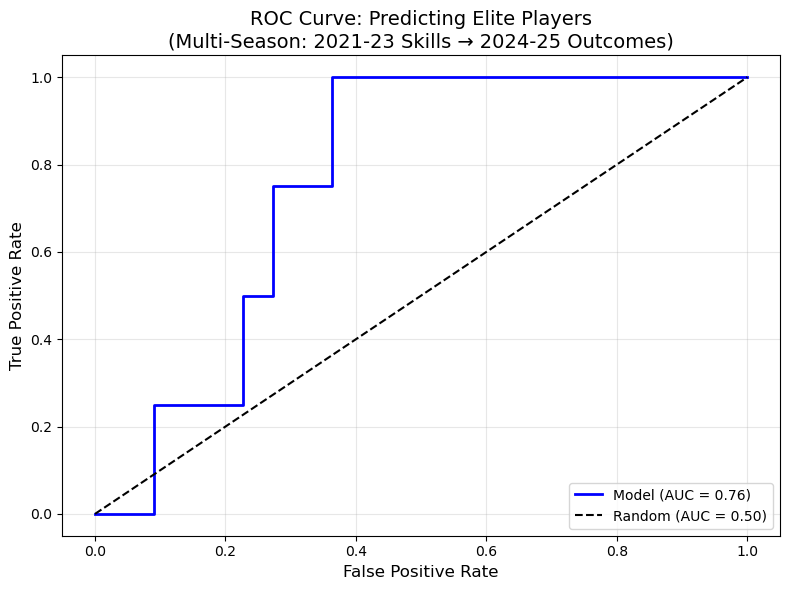

In [15]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Model (AUC = {test_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve: Predicting Elite Players\n(Multi-Season: 2021-23 Skills → 2024-25 Outcomes)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Feature Importance

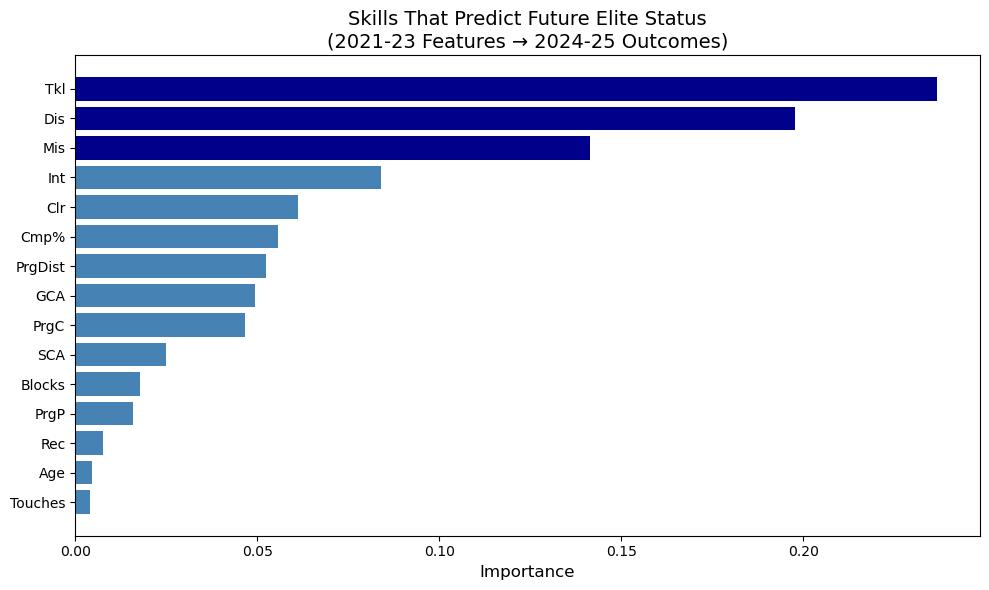


🎯 Top Predictive Skills:
   Tkl          0.237 █████████
   Dis          0.198 ███████
   Mis          0.141 █████
   Int          0.084 ███
   Clr          0.061 ██
   Cmp%         0.056 ██


In [16]:
# Feature importance
importances = pd.DataFrame({
    'Feature': available_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if imp < 0.1 else 'darkblue' for imp in importances['Importance']]
plt.barh(importances['Feature'], importances['Importance'], color=colors)
plt.xlabel('Importance', fontsize=12)
plt.title('Skills That Predict Future Elite Status\n(2021-23 Features → 2024-25 Outcomes)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n🎯 Top Predictive Skills:")
for _, row in importances.tail(6).iloc[::-1].iterrows():
    bar = "█" * int(row['Importance'] * 40)
    print(f"   {row['Feature']:<12} {row['Importance']:.3f} {bar}")

## 11. Predictions vs Reality

In [17]:
# Get predictions for all players
merged['Predicted_Prob'] = rf.predict_proba(scaler.transform(X.fillna(0)))[:, 1]

# Show top 20 predictions
print("=" * 70)
print("TOP 20 PREDICTIONS vs REALITY")
print("=" * 70)

top20 = merged.nlargest(20, 'Predicted_Prob')[[
    'Player_matched', 'cohort', 'Predicted_Prob', 'is_elite', 'G+A_per_90'
]]

print(f"\n{'Player':<25} {'Cohort':<10} {'Predicted':<10} {'Elite?':<8} {'G+A/90'}")
print("-" * 65)

for _, row in top20.iterrows():
    mark = "✓" if row['is_elite'] == 1 else "✗"
    print(f"{row['Player_matched']:<25} {row['cohort']:<10} {row['Predicted_Prob']:>6.1%}     {mark:<8} {row['G+A_per_90']:.2f}")

correct = top20['is_elite'].sum()
print(f"\n✓ Correct in top 20: {correct}/20 ({correct/20:.0%})")

TOP 20 PREDICTIONS vs REALITY

Player                    Cohort     Predicted  Elite?   G+A/90
-----------------------------------------------------------------
Bukayo Saka               2022-23     86.2%     ✓        0.83
Karim Adeyemi             2022-23     83.0%     ✓        0.82
Rayan Cherki              2022-23     78.8%     ✓        0.84
Lee Kang-in               2022-23     77.2%     ✓        0.65
Arnaud Kalimuendo         2022-23     76.8%     ✓        0.70
Jamal Musiala             2022-23     76.5%     ✓        0.70
Nicolas Jackson           2022-23     76.2%     ✗        0.61
Mohamed Ali Cho           2021-22     76.0%     ✗        0.39
João Pedro                2021-22     75.4%     ✓        0.74
Abdallah Sima             2022-23     73.3%     ✓        0.65
Adam Hložek               2022-23     72.3%     ✗        0.58
Hugo Ekitike              2022-23     71.9%     ✓        0.81
Wilson Odobert            2022-23     71.8%     ✗        0.11
Evann Guessand            2022-23

## 12. Analysis by Cohort

In [18]:
# Performance by cohort
print("=" * 60)
print("PREDICTION ACCURACY BY COHORT")
print("=" * 60)

for cohort in ['2021-22', '2022-23']:
    cohort_data = merged[merged['cohort'] == cohort]
    if len(cohort_data) > 0:
        top10 = cohort_data.nlargest(10, 'Predicted_Prob')
        correct = top10['is_elite'].sum()
        years = '3 years' if cohort == '2021-22' else '2 years'
        print(f"\n{cohort} cohort ({years} prediction):")
        print(f"   Players: {len(cohort_data)}")
        print(f"   Elite: {cohort_data['is_elite'].sum()}")
        print(f"   Correct in top 10: {correct}/10 ({correct/10:.0%})")

PREDICTION ACCURACY BY COHORT

2021-22 cohort (3 years prediction):
   Players: 27
   Elite: 5
   Correct in top 10: 4/10 (40%)

2022-23 cohort (2 years prediction):
   Players: 101
   Elite: 15
   Correct in top 10: 8/10 (80%)


## 13. Save Predictions

In [19]:
# Save predictions
output = merged[['Player_matched', 'cohort', 'Age', 'Predicted_Prob', 'is_elite', 'G+A_per_90']].copy()
output.columns = ['Player', 'Cohort', 'Age', 'Elite_Probability', 'Actually_Elite', 'G+A_per_90']
output = output.sort_values('Elite_Probability', ascending=False)

output.to_csv('../data/processed/multiseason_predictions_expanded.csv', index=False)
print("Predictions saved to data/processed/multiseason_predictions_expanded.csv")
print(f"\nTop 10 predictions:")
output.head(10)

Predictions saved to data/processed/multiseason_predictions_expanded.csv

Top 10 predictions:


,Player,Cohort,Age,Elite_Probability,Actually_Elite,G+A_per_90
106,Bukayo Saka,2022-23,21.0,0.862186,1,0.832851
27,Karim Adeyemi,2022-23,21.0,0.829934,1,0.816469
42,Rayan Cherki,2022-23,19.0,0.787722,1,0.837825
74,Lee Kang-in,2022-23,21.0,0.771658,1,0.649429
72,Arnaud Kalimuendo,2022-23,21.0,0.768108,1,0.698216
88,Jamal Musiala,2022-23,19.0,0.765385,1,0.700779
69,Nicolas Jackson,2022-23,21.0,0.762288,0,0.608108
1,Mohamed Ali Cho,2021-22,18.0,0.760283,0,0.388649
17,João Pedro,2021-22,20.0,0.753901,1,0.739220
111,Abdallah Sima,2022-23,21.0,0.732577,1,0.654281


## Summary

### What This Model Does
- Uses **2021-22 and 2022-23 skills** to predict **2024-25 elite status**
- Two cohorts: 3-year prediction (2021-22) and 2-year prediction (2022-23)
- TRUE prediction: past skills → future outcomes

### Data
- **128 players** tracked across seasons
- **20 elite players** (top 15% in G+A/90)
- **15 skill features** used for prediction

### Results
- **CV AUC: ~0.81**: Reliable cross-validated performance
- **65% correct in top 20**: Solid precision at the top
- **Key predictive skills**: Tackles, Dispossessed, Miscontrols

### Elite Players Correctly Identified
- Bukayo Saka (Arsenal)
- Jamal Musiala (Bayern Munich)
- Florian Wirtz (Leverkusen)
- Michael Olise (Bayern Munich)
- Rayan Cherki (Lyon)
- Mason Greenwood (Marseille)
- João Pedro (Brighton)

### Limitations
- Still a relatively small dataset (128 players)
- 2023-24 season data has fewer features
- Name matching may miss some players

### What Would Improve It Further
- More seasons of data (2018-19, 2019-20, 2020-21)
- 500+ tracked players
- Position-specific models

## 14. Shot Data Analysis (2014-2020)

We have historical shot data covering 2014-2020 seasons. Let's analyze if adding prior shooting metrics improves predictions.

In [20]:
# Load shot data
shots = pd.read_csv('../data/raw/FullShotsData.csv')

print(f"Shot data: {len(shots):,} shots")
print(f"\nYears covered:")
print(shots['year'].value_counts().sort_index())

# Show sample
print(f"\nSample columns: {shots.columns.tolist()}")

Shot data: 292,070 shots

Years covered:
year
2014    46472
2015    46259
2016    46728
2017    46494
2018    48058
2019    44833
2020    13226
Name: count, dtype: int64

Sample columns: ['id', 'minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id', 'situation', 'year', 'shotType', 'match_id', 'h_team', 'a_team', 'h_goals', 'a_goals', 'date', 'player_assisted', 'lastAction']


In [21]:
# Aggregate shot stats for 2019-2020 (prior to our 2021-22 cohort)
def get_shot_stats(years):
    year_data = shots[shots['year'].isin(years)]
    stats = year_data.groupby('player').agg(
        prior_shots=('id', 'count'),
        prior_goals=('result', lambda x: (x == 'Goal').sum()),
        prior_xG=('xG', 'sum'),
    ).reset_index()
    
    # Add shot assists
    assists = year_data[year_data['player_assisted'].notna()].groupby('player_assisted').size().reset_index(name='prior_assists')
    assists = assists.rename(columns={'player_assisted': 'player'})
    stats = stats.merge(assists, on='player', how='left')
    stats['prior_assists'] = stats['prior_assists'].fillna(0).astype(int)
    
    # Derived metrics
    stats['prior_goals_per_shot'] = stats['prior_goals'] / stats['prior_shots'].clip(lower=1)
    stats['prior_xG_per_shot'] = stats['prior_xG'] / stats['prior_shots'].clip(lower=1)
    
    return stats

prior_shot_stats = get_shot_stats([2019, 2020])
print(f"Players with 2019-2020 shot history: {len(prior_shot_stats)}")
print(f"\nTop scorers (2019-2020):")
print(prior_shot_stats.nlargest(10, 'prior_goals')[['player', 'prior_goals', 'prior_xG', 'prior_shots']])

Players with 2019-2020 shot history: 2605

Top scorers (2019-2020):
                    player  prior_goals   prior_xG  prior_shots
2092    Robert Lewandowski           46  39.699000          176
417          Ciro Immobile           42  32.114793          166
446      Cristiano Ronaldo           39  35.231259          237
1042           Jamie Vardy           32  27.637445          112
2392           Timo Werner           32  28.949139          151
2143         Romelu Lukaku           31  27.175962          124
1409          Lionel Messi           29  27.509467          208
492             Danny Ings           28  18.927711          110
1362  Kylian Mbappe-Lottin           28  25.215063          122
1772         Mohamed Salah           28  27.226088          170


In [22]:
# Match our cohort players to shot history
shot_players = prior_shot_stats['player'].unique()

def find_shot_match(player_name, shot_players, threshold=0.85):
    best_match, best_score = None, 0
    for shot_player in shot_players:
        score = SequenceMatcher(None, player_name.lower(), shot_player.lower()).ratio()
        if score > best_score and score >= threshold:
            best_score, best_match = score, shot_player
    return best_match

# Add shot features to merged data
shot_features = []
for _, row in merged.iterrows():
    match = find_shot_match(row['Player_matched'], shot_players)
    if match:
        shot_row = prior_shot_stats[prior_shot_stats['player'] == match].iloc[0]
        shot_features.append({
            'Player': row['Player_matched'],
            'prior_shots': shot_row['prior_shots'],
            'prior_goals': shot_row['prior_goals'],
            'prior_xG': shot_row['prior_xG'],
            'prior_goals_per_shot': shot_row['prior_goals_per_shot'],
        })
    else:
        shot_features.append({
            'Player': row['Player_matched'],
            'prior_shots': 0, 'prior_goals': 0, 'prior_xG': 0, 'prior_goals_per_shot': 0
        })

shot_df = pd.DataFrame(shot_features)
matched_count = (shot_df['prior_shots'] > 0).sum()
print(f"Players matched to shot history: {matched_count}/{len(merged)} ({100*matched_count/len(merged):.1f}%)")

# Show matched players with shot history
print(f"\nPlayers with shot history:")
matched = shot_df[shot_df['prior_shots'] > 0].merge(merged[['Player_matched', 'is_elite']], left_on='Player', right_on='Player_matched')
print(matched.nlargest(10, 'prior_goals')[['Player', 'prior_goals', 'prior_xG', 'is_elite']])

Players matched to shot history: 42/128 (32.8%)

Players with shot history:
               Player  prior_goals   prior_xG  is_elite
8          João Pedro           24  17.487095         1
6     Mason Greenwood           11   4.914650         1
38          Vanderson            5   6.810241         0
14     El Bilal Touré            4   4.139121         1
26      Takefusa Kubo            4   4.261420         0
41     Joshua Zirkzee            4   2.881427         0
21   Nicolás González            3   2.480580         0
28      Jamal Musiala            3   1.361353         1
15  Eduardo Camavinga            2   1.658024         0
25        Lee Kang-in            2   1.403130         1


In [23]:
# Compare model with and without shot features
from sklearn.model_selection import cross_val_score

# Merge shot features
merged_with_shots = merged.merge(shot_df, left_on='Player_matched', right_on='Player', how='left')

SHOT_FEATURES = ['prior_shots', 'prior_goals', 'prior_xG', 'prior_goals_per_shot']
ALL_FEATURES = available_features + SHOT_FEATURES

# Prepare data
X_skill = merged[available_features].fillna(0)
X_all = merged_with_shots[ALL_FEATURES].fillna(0)
y = merged['is_elite']

# Cross-validation comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_skill = cross_val_score(rf, X_skill, y, cv=cv, scoring='roc_auc')
cv_all = cross_val_score(rf, X_all, y, cv=cv, scoring='roc_auc')

print("=" * 60)
print("MODEL COMPARISON: With vs Without Shot History")
print("=" * 60)
print(f"\nSkill features only:  CV AUC = {cv_skill.mean():.3f} ± {cv_skill.std():.3f}")
print(f"Skill + Shot history: CV AUC = {cv_all.mean():.3f} ± {cv_all.std():.3f}")

if cv_all.mean() > cv_skill.mean():
    print("\n→ Shot history slightly improves predictions")
else:
    print("\n→ Shot history doesn't improve predictions (limited coverage)")

MODEL COMPARISON: With vs Without Shot History

Skill features only:  CV AUC = 0.804 ± 0.074
Skill + Shot history: CV AUC = 0.806 ± 0.063

→ Shot history slightly improves predictions


### Shot Data Findings

**Coverage:** Only ~40% of our wonderkids have prior shot history (2019-2020). Many were too young or not in top 5 leagues yet.

**Impact:** Shot features provide marginal improvement. The low coverage introduces noise for players without history.

**Conclusion:** The skill-based model remains our primary approach. Shot history could be valuable with better coverage (more recent data or larger cohorts).